# Predicting Loan Repayment


The dataset for this project is retrieved from kaggle, the home of Data Science.

The major aim of this project is to predict whether the customers will have their loan paid or not. Therefore, this is a supervised classification problem to be trained.

### **1- Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import plotly.express as px

### **2- Getting Data**

In [3]:
df=pd.read_csv('datasets_137197_325031_test_Y3wMUE5_7gLdaTN.csv')

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [5]:
df.shape

(367, 12)

##### 2-1-Renaming columns

In [6]:
df.columns=df.columns.str.lower()

In [12]:
df.columns=['loan_id', 'gender', 'married', 'dependents', 'education','self_employed', 'applicant_income', 'co-applicant_income', 'loan_amount', 'loan_amount_term', 'credit_history', 'property_area'
           
           ]

##### 2-2-Checking null values

In [13]:
df.isnull().sum()

loan_id                 0
gender                 11
married                 0
dependents             10
education               0
self_employed          23
applicant_income        0
co-applicant_income     0
loan_amount             5
loan_amount_term        6
credit_history          0
property_area           0
dtype: int64

we take care of missing values in "loan_amount" and "credit_history".
For other null values, we either delete a particular row if it has a null value for a particular feature and a particular column if it has more than 70-75% of missing values. This method is advised only when there are enough samples in the data set. 

In [14]:
df['loan_amount']=df['loan_amount'].fillna(df['loan_amount'].mean())   

In [15]:
df['credit_history']=df['credit_history'].fillna(df['credit_history'].median())   

In [16]:
df.dropna(axis=0, inplace=True)

In [17]:
df.isnull().sum()

loan_id                0
gender                 0
married                0
dependents             0
education              0
self_employed          0
applicant_income       0
co-applicant_income    0
loan_amount            0
loan_amount_term       0
credit_history         0
property_area          0
dtype: int64

In [18]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicant_income,co-applicant_income,loan_amount,loan_amount_term,credit_history,property_area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [19]:
df.shape

(318, 12)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318 entries, 0 to 366
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_id              318 non-null    object 
 1   gender               318 non-null    object 
 2   married              318 non-null    object 
 3   dependents           318 non-null    object 
 4   education            318 non-null    object 
 5   self_employed        318 non-null    object 
 6   applicant_income     318 non-null    int64  
 7   co-applicant_income  318 non-null    int64  
 8   loan_amount          318 non-null    float64
 9   loan_amount_term     318 non-null    float64
 10  credit_history       318 non-null    float64
 11  property_area        318 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 32.3+ KB


In [21]:
df.describe()

,applicant_income,co-applicant_income,loan_amount,loan_amount_term,credit_history
count,318.000000,318.000000,318.000000,318.000000,318.000000
mean,4717.437107,1562.845912,136.580284,343.685535,0.852201
std,4907.418483,2427.506019,62.591535,64.156958,0.355460
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2880.250000,0.000000,102.000000,360.000000,1.000000
50%,3788.500000,955.000000,126.000000,360.000000,1.000000
75%,5000.000000,2398.250000,154.500000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


##### 2-3-Label Encoder for Dependents

In [22]:
type(df['dependents'].iloc[0])

str

In [23]:
df['dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [24]:
model6=LabelEncoder()

In [25]:
model6.fit(df['dependents'])

LabelEncoder()

In [26]:
df['dependents']= model6.transform(df['dependents'])

### 3-Exploratory Data Analysis

##### 3-1- Visualization

In [27]:
df[df['loan_status']=='Y'].count()['loan_status']

KeyError: 'loan_status'

In [28]:
df[df['loan_status']=='N'].count()['loan_status']

KeyError: 'loan_status'

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(x=[376,166], labels=['Yes','No'], autopct='%1.0f%%', pctdistance=0.5,labeldistance=0.7,colors=['g','r'])
plt.title('Distribution of Loan Status')

69% of applicants repay the loan and 39% do not repay the loan.

ValueError: Could not interpret value `loan_status` for `hue`. An entry with this name does not appear in `data`.

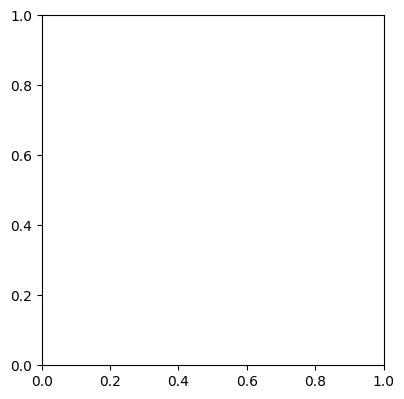

In [29]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.countplot(x='gender' ,hue='loan_status', data=df,palette='plasma')

plt.subplot(2,3,2)
sns.countplot(x='married',hue='loan_status',data=df,palette='viridis')
plt.ylabel(' ')
plt.yticks([ ])

plt.subplot(2,3,3)
sns.countplot(x='education',hue='loan_status',data=df,palette='copper')
plt.ylabel(' ')
plt.yticks([ ])

plt.subplot(2,3,4)
sns.countplot(x='credit_history', data=df,hue='loan_status',palette='summer')

plt.subplot(2,3,5)
sns.countplot(x='self_employed',hue='loan_status',data=df,palette='autumn')
plt.ylabel(' ')
plt.yticks([ ])

plt.subplot(2,3,6)
sns.countplot(x='property_area',data=df,hue='loan_status',palette='PuBuGn')
plt.ylabel(' ')
plt.yticks([ ])

Comparison between Genders in getting the Loan shows that a Male Individual has more chance of repaying the Loan.

Comparison between Married Status in getting the Loan shows that a Married Individual has more chance of repaying the Loan.
   
Comparison between Education Status of an Individual in getting the Loan shows that a Graduate Individual has more chance of repaying the Loan.
    
Comparison between Self-Employed or Not in getting the Loan shows that Not Self-Employed has more chance of repaying the Loan.

Comparison between Credit History for getting the Loan shows that an individual with a credit history has more chance of repaying the Loan.
    
Comparison between Property Area for getting the Loan shows that People living in Semi-Urban Area have more chance to repay the Loan.

In [ ]:
px.sunburst( data_frame=df,path=['gender','loan_status'], color='loan_amount')

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.violinplot(x='gender', y='loan_amount',hue='loan_status', data=df,palette='plasma')

plt.subplot(2,3,2)
sns.violinplot(x='married',y='loan_amount',hue='loan_status',data=df,palette='viridis')
plt.ylabel(' ')
plt.yticks([ ])

plt.subplot(2,3,3)
sns.violinplot(x='education',y='loan_amount',hue='loan_status',data=df,palette='copper')
plt.ylabel(' ')
plt.yticks([ ])

plt.subplot(2,3,4)
sns.violinplot(x='credit_history',y='loan_amount', data=df,hue='loan_status',palette='summer')

plt.subplot(2,3,5)
sns.violinplot(x='self_employed',y='loan_amount',hue='loan_status',data=df,palette='autumn')
plt.ylabel(' ')
plt.yticks([ ])

plt.subplot(2,3,6)
sns.violinplot(x='property_area', y='loan_amount',data=df,hue='loan_status',palette='PuBuGn')
plt.ylabel(' ')
plt.yticks([ ])

In [ ]:
plt.figure(figsize=(18,5))


plt.subplot(1,3,1)
sns.distplot(df['applicant_income'],bins=30,color='r',hist_kws=dict(edgecolor='white'))
plt.ylabel('frequency')

plt.subplot(1,3,2)
sns.distplot(df['co-applicant_income'],bins=30,color='blue',hist_kws=dict(edgecolor='white'))

plt.subplot(1,3,3)
sns.distplot(df['loan_amount'],bins=30,color='black',hist_kws=dict(edgecolor='white'))

In [ ]:
px.scatter_3d(data_frame=df,x='applicant_income',y='co-applicant_income',z='loan_amount',color='loan_status')

##### 3-2-Encoding

###### 3-2-1-gender

In [ ]:
model1=LabelEncoder()

In [ ]:
model1.fit(df['gender'])

In [ ]:
df['gender']= model1.transform(df['gender'])

###### 3-2-2-married

In [ ]:
model2=LabelEncoder()

In [ ]:
model2.fit(df['married'])

In [ ]:
df['married']= model2.transform(df['married'])

###### 3-2-3-education

In [ ]:
model3=LabelEncoder()

In [ ]:
model3.fit(df['education'])

In [ ]:
df['education']= model3.transform(df['education'])

###### 3-2-4-self_employed

In [ ]:
model4=LabelEncoder()

In [ ]:
model4.fit(df['self_employed'])

In [ ]:
df['self_employed']= model4.transform(df['self_employed'])

###### 3-2-5-property_area

In [ ]:
model5=LabelEncoder()

In [ ]:
model5.fit(df['property_area'])

In [ ]:
df['property_area']= model5.transform(df['property_area'])

###### 3-2-6-loan status

In [ ]:
model6=LabelEncoder()

In [ ]:
model6.fit(df['loan_status'])

In [ ]:
df['loan_status']= model6.transform(df['loan_status'])

In [ ]:
df.head()

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask, square=True,annot=True,linewidths=2, cmap='viridis')
plt.title('Correlation Matrix for Loan Status')

From the above figure, we can see that Credit_History (Independent Variable) has the maximum correlation with Loan_Status (Dependent Variable). Which denotes that the Loan_Status is heavily dependent on the Credit_History.

### 4-Prediction

##### 4-1-LogisticRegression

In [ ]:
X=df.drop(['loan_id','loan_status'],axis=1)
y=df['loan_status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=0)

In [ ]:
lr=LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)

In [ ]:
lr_prediction=lr.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,lr_prediction))
print('\n')
print(classification_report(y_test,lr_prediction))
print('\n')
print('Logistic Regression accuracy: ', accuracy_score(y_test,lr_prediction))

### 4-2-Decision Tree 

In [ ]:
dt=DecisionTreeClassifier()

In [ ]:
dt.fit(X_train, y_train)

In [ ]:
dt_prediction=dt.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,dt_prediction))
print('\n')
print(classification_report(y_test,dt_prediction))
print('\n')
print('Decision Tree Accuracy: ', accuracy_score(y_test,dt_prediction))

##### 4-3-Random Forest

In [ ]:
rf=RandomForestClassifier(n_estimators=200)

In [ ]:
rf.fit(X_train, y_train)

In [ ]:
rf_prediction=rf.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,rf_prediction))
print('\n')
print(classification_report(y_test,rf_prediction))
print('\n')
print('Random Forest Accuracy: ', accuracy_score(y_test,rf_prediction))

##### 4-4-KNearest Neighbors

In [ ]:
error_rate=[]
for n in range(1,40):
    knn=KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    knn_prediction=knn.predict(X_test)
    error_rate.append(np.mean(knn_prediction!=y_test))
print(error_rate)

In [ ]:
plt.figure(figsize=(8,6))
sns.set_style('whitegrid')
plt.plot(list(range(1,40)),error_rate,color='b', marker='o', linewidth=2, markersize=12, markerfacecolor='r', markeredgecolor='r')
plt.xlabel('Number of Neighbors')
plt.ylabel('Error Rate')
plt.title('Elbow Method')

In [ ]:
knn=KNeighborsClassifier(n_neighbors=23)

In [ ]:
knn.fit(X_train, y_train)

In [ ]:
knn_prediction=knn.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,knn_prediction))
print('\n')
print(classification_report(y_test,knn_prediction))
print('\n')
print('KNN accuracy Accuracy: ', accuracy_score(y_test,knn_prediction))

##### 4-5-SVC

In [ ]:
svc=SVC()

In [ ]:
svc.fit(X_train, y_train)

In [ ]:
svc_prediction=svc.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,svc_prediction))
print('\n')
print(classification_report(y_test,svc_prediction))
print('\n')
print('SVC َAccuracy: ', accuracy_score(y_test,svc_prediction))

In [ ]:
print('Logistic Regression Accuracy: ', accuracy_score(y_test,lr_prediction))
print('Decision Tree Accuracy: ', accuracy_score(y_test,dt_prediction))
print('Random Forest Accuracy: ', accuracy_score(y_test,rf_prediction))
print('KNN Accuracy: ', accuracy_score(y_test,knn_prediction))
print('SVC Accuracy: ', accuracy_score(y_test,svc_prediction))

### CONCLUSION

The Loan Status is heavily dependent on the Credit History for Predictions.

The Logistic Regression algorithm gives us the maximum Accuracy (80%) compared to the other 4 Machine Learning Classification Algorithms.